# GPU support in scikit-learn with the Array API

## Example of a complex non-linear regression pipeline

At the time of writing, this notebook requires experimental features only available in the developer version of scikit-learn:

In [1]:
# %pip uninstall -q -y sklearn-compat
# %pip install -q -U --pre --extra-index https://pypi.anaconda.org/scientific-python-nightly-wheels/simple scikit-learn

Let's enable the Array API support in SciPy and scikit-learn. See the scikit-learn documentation for more details:

https://scikit-learn.org/dev/modules/array_api.html

In [2]:
import os
import sklearn

os.environ["SCIPY_ARRAY_API"] = "1"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
sklearn.set_config(array_api_dispatch=True)

Let's define a low dimensional (2D) regression problem. Both the mean and variance of the target variable depend on the input features.

In [3]:
import numpy as np
import torch


def true_mean(X):
    return np.sin(X[:, 0] * 2) * np.cos(X[:, 1]) ** 4


def true_std(X):
    return 0.2 * np.cos(X[:, 1]) ** 6


def make_data(n_samples=int(1e5), seed=0):
    rng = np.random.default_rng(seed=seed)
    X = rng.uniform(low=-3, high=3, size=(n_samples, 2))
    y = rng.normal(loc=true_mean(X), scale=true_std(X))
    return X.astype(np.float32), y.astype(np.float32)


X, y = make_data()


In [4]:
if torch.backends.cuda.is_built():
    gpu_device = "cuda"
elif torch.backends.mps.is_built():
    gpu_device = "mps"
else:
    print("No GPU device found, falling back to CPU...")
    gpu_device = "cpu"

X_torch_gpu = torch.asarray(X, device=gpu_device)
y_torch_gpu = torch.asarray(y, device=gpu_device)
gpu_device

'mps'


The **non-linear interactions** of the features makes the regression problem more complex: a simple linear regression model would not be well-specified for this task.

The feature dependent variance of the target variable makes this problem an **heteroscedastic** regression problem. This would be important to keep in mind if we were to model prediction uncertainty but we will leave that aside for this notebook and only focus on modeling the conditional mean of the target.

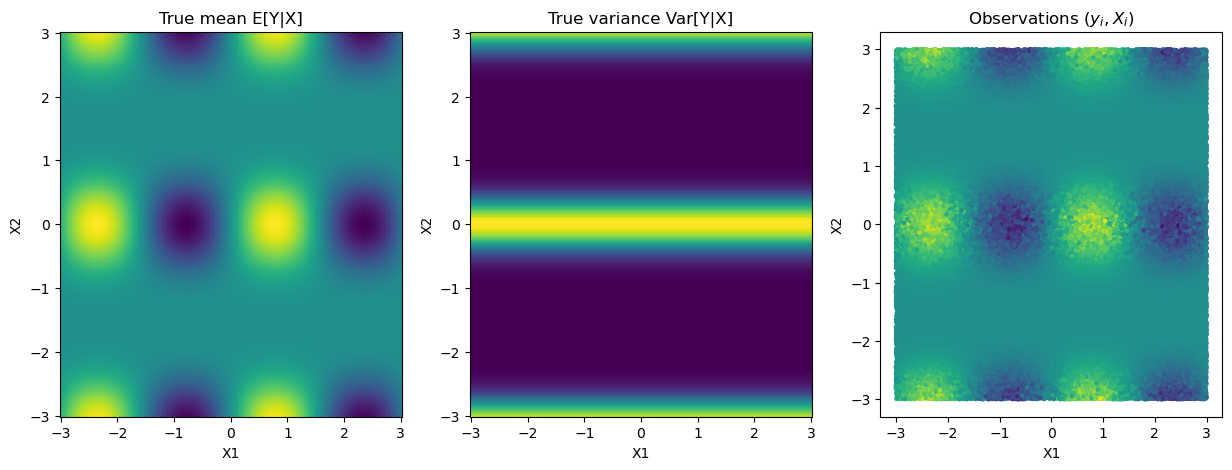

In [5]:
import matplotlib.pyplot as plt

x1 = np.linspace(-3, 3, 200).astype(np.float32)
x2 = np.linspace(-3, 3, 200).astype(np.float32)
X1, X2 = np.meshgrid(x1, x2)

fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
axs[0].pcolormesh(X1, X2, true_mean(np.c_[X1.ravel(), X2.ravel()]).reshape(*X1.shape))
axs[0].set(title="True mean E[Y|X]", xlabel="X1", ylabel="X2")
axs[1].pcolormesh(X1, X2, true_std(np.c_[X1.ravel(), X2.ravel()]).reshape(*X1.shape) ** 2)
axs[1].set(title="True variance Var[Y|X]", xlabel="X1", ylabel="X2")
axs[2].scatter(X[:, 0], X[:, 1], c=y, s=5)
axs[2].set(title="Observations $(y_i, X_i)$", xlabel="X1", ylabel="X2");

This is a medium-size machine learning problem. The total dataset contains 100k observations in a 2D space. This represents less than a MB of data.

In [6]:
X.shape

(100000, 2)

In [7]:
X.nbytes / 1e6

0.8

Let's estimate the Bayes error rate for this data generating process. The vast majority of the variability of the target `y` can be explained by the input features in `X`.

In [8]:
from sklearn.metrics import r2_score

r2_score(y, true_mean(X))

0.9436010718345642

In the following we will attempt to compose scikit-learn building block to train a model that estimates this mean function as accurately as possible from the available data points.

We first consider a polynomial regression pipeline fit on the CPU using the default NumPy & SciPy-based implementations that comes with scikit-learn:

In [9]:
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import RidgeCV
from sklearn.kernel_approximation import Nystroem
from sklearn.model_selection import cross_validate


poly_reg_numpy_cpu = make_pipeline(
    SplineTransformer(n_knots=5),
    Nystroem(kernel="poly", degree=2, n_components=300, random_state=0),
    RidgeCV(alphas=np.logspace(-6, 6, 13)),
)
poly_reg_numpy_cpu

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('splinetransformer', ...), ('nystroem', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_knots n_knots: int, default=5Number of knots of the splines if `knots` equals one of{'uniform', 'quantile'}. Must be larger or equal 2. Ignored if `knots`is array-like.",5
,"degree degree: int, default=3The polynomial degree of the spline basis. Must be a non-negativeinteger.",3
,"knots knots: {'uniform', 'quantile'} or array-like of shape (n_knots, n_features), default='uniform'Set knot positions such that first knot <= features <= last knot.- If 'uniform', `n_knots` number of knots are distributed uniformly from min to max values of the features.- If 'quantile', they are distributed uniformly along the quantiles of the features.- If an array-like is given, it directly specifies the sorted knot positions including the boundary knots. Note that, internally, `degree` number of knots are added before the first knot, the same after the last knot.",'uniform'
,"extrapolation extrapolation: {'error', 'constant', 'linear', 'continue', 'periodic'}, default='constant'If 'error', values outside the min and max values of the trainingfeatures raises a `ValueError`. If 'constant', the value of thesplines at minimum and maximum value of the features is used asconstant extrapolation. If 'linear', a linear extrapolation is used.If 'continue', the splines are extrapolated as is, i.e. option`extrapolate=True` in :class:`scipy.interpolate.BSpline`. If'periodic', periodic splines with a periodicity equal to the distancebetween the first and last knot are used. Periodic splines enforceequal function values and derivatives at the first and last knot.For example, this makes it possible to avoid introducing an arbitraryjump between Dec 31st and Jan 1st in spline features derived from anaturally periodic ""day-of-year"" input feature. In this case it isrecommended to manually set the knot values to control the period.",'constant'
,"include_bias include_bias: bool, default=TrueIf False, then the last spline element inside the data rangeof a feature is dropped. As B-splines sum to one over the spline basisfunctions for each data point, they implicitly include a bias term,i.e. a column of ones. It acts as

In [10]:
%%time
cv_results_numpy_cpu = cross_validate(poly_reg_numpy_cpu, X, y, cv=5)
pd.DataFrame(cv_results_numpy_cpu)[["test_score", "fit_time", "score_time"]].round(3)

CPU times: user 4.59 s, sys: 1.73 s, total: 6.33 s
Wall time: 6.52 s


,test_score,fit_time,score_time
0,0.812,1.544,0.020
1,0.806,1.234,0.012
2,0.809,1.259,0.011
3,0.799,1.193,0.012
4,0.806,1.214,0.011


Fitting and evaluating the pipeline 5 times on the 2 CPU cores takes around 30 s on the base Google Colab host and 10 s with more powerful runtimes.

Note that this pipeline has many hyper-parameters to adjust. Tweaking them interactively with a 30 s long iterations is not feasible: the data scientist will often loose their focus.

Conducting a systematic hyper-parameter tuning sweap would require more CPUs on a beafier dedicated machine and would also break the interactive user experience.

Let's instead adapt the pipeline to move the last two steps (which happen to be the linear-algebra heavy steps) to the GPU with the help of PyTorch:

In [14]:
%%time
from sklearn.preprocessing import FunctionTransformer
from functools import partial


poly_reg_torch_gpu = make_pipeline(
    SplineTransformer(n_knots=5),
    FunctionTransformer(partial(torch.asarray, device=gpu_device)),
    Nystroem(kernel="poly", degree=2, n_components=300, random_state=0),
    RidgeCV(alphas=np.logspace(-6, 6, 13)),
)

cv_results_torch_gpu = cross_validate(
    poly_reg_torch_gpu, X, y_torch_gpu, cv=5, return_estimator=True, error_score="raise"
)
pd.DataFrame(cv_results_torch_gpu)[["test_score", "fit_time", "score_time"]].round(3)

CPU times: user 368 ms, sys: 212 ms, total: 580 ms
Wall time: 1.98 s


,test_score,fit_time,score_time
0,0.848,0.557,0.023
1,0.831,0.323,0.027
2,0.831,0.331,0.017
3,0.835,0.313,0.024
4,0.831,0.330,0.025


Let's qualitatively check the learned prediction function of the models trained for the each iteration of this cross-validation:

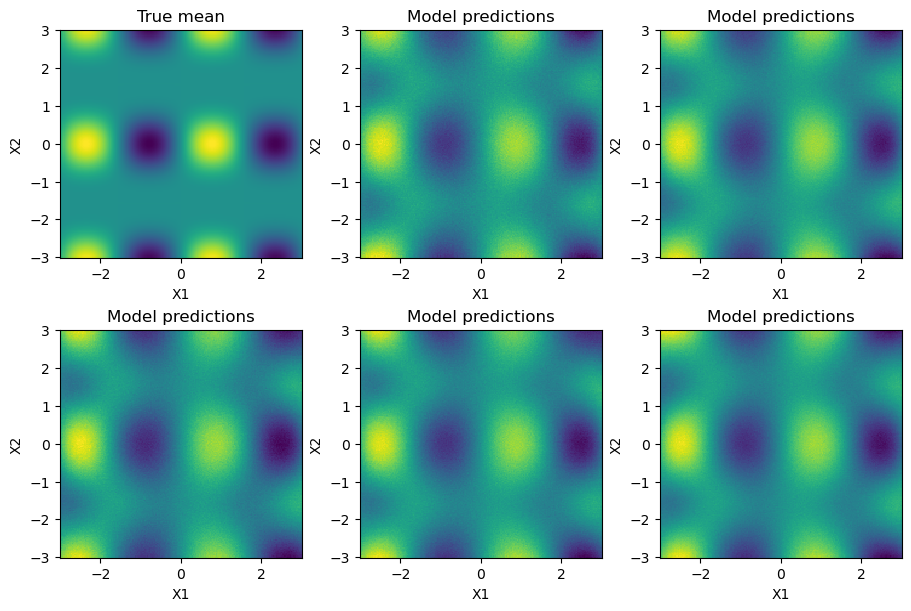

In [12]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(9, 6), constrained_layout=True)
axs[0, 0].pcolormesh(X1, X2, true_mean(np.c_[X1.ravel(), X2.ravel()]).reshape(*X1.shape))
axs[0, 0].set(title="True mean", xlabel="X1", ylabel="X2")
for est, ax in zip(cv_results_torch_gpu["estimator"], axs.ravel()[1:]):
    ax.pcolormesh(X1, X2, est.predict(np.c_[X1.ravel(), X2.ravel()]).reshape(*X1.shape).cpu())
    ax.set(title="Model predictions", xlabel="X1", ylabel="X2");

The resulting pipeline is both qualitatitively and quantitative far from optimal.

But since fitting this pipeline is now much faster, let's try to tune the hyperparameters:

In [23]:
%%time
from sklearn.model_selection import RandomizedSearchCV


param_grid = dict(
    splinetransformer__n_knots=range(3, 30),
    nystroem__kernel=["poly", "rbf"],
    nystroem__degree=[2, 3, 4, 5],
    nystroem__gamma=np.logspace(-6, 6, 100),
    nystroem__n_components=[50, 100, 200, 500],
    # ridge__alpha=np.logspace(-6, 6, 100),
)

search_cv = RandomizedSearchCV(
    poly_reg_torch_gpu,
    param_grid,
    n_iter=30,
    random_state=0,
)
search_cv.fit(X, y_torch_gpu)

CPU times: user 8.71 s, sys: 2.62 s, total: 11.3 s
Wall time: 40.6 s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step..., 1.e+06])))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'nystroem__degree': [2, 3, ...], 'nystroem__gamma': array([1.0000...00000000e+06]), 'nystroem__kernel': ['poly', 'rbf'], 'nystroem__n_components': [50, 100, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratifie

In [24]:
search_cv.best_score_.round(3)

np.float64(0.941)

The cross-validation score of the best model is very close to the Bayes optimal score computed from our knowledge of the data-generating process!

Let's qualitatively compare our mean estimate to the ground truth of the data generating process.

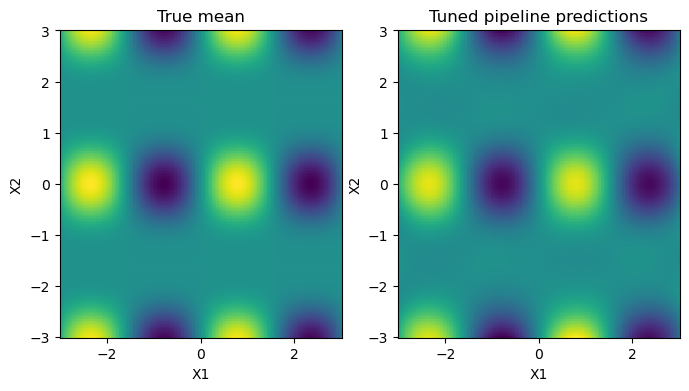

In [25]:
best_model = search_cv.best_estimator_

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
axs[0].pcolormesh(X1, X2, true_mean(np.c_[X1.ravel(), X2.ravel()]).reshape(*X1.shape))
axs[0].set(title="True mean", xlabel="X1", ylabel="X2")
axs[1].pcolormesh(X1, X2, best_model.predict(np.c_[X1.ravel(), X2.ravel()]).reshape(*X1.shape).cpu())
axs[1].set(title="Tuned pipeline predictions", xlabel="X1", ylabel="X2");

We see a very good match: it's hard to visually identify any defect once the hyparameters have been tuned.

Thanks to **GPU** acceleration, we can **tune the hyperparamters** a complex pipeline to get a very good model **in the time it would take to run a single cross-validation** on the Google Colab CPU.

More importantly, the training speed is fast enough to **avoid disrupting the model development flow** of the data scientist editing the Google Colab notebook **interactively**.


Let's have a look at the optimal hyper-parameter combinations:

In [26]:
search_cv.best_params_

{'splinetransformer__n_knots': 3,
 'nystroem__n_components': 200,
 'nystroem__kernel': 'rbf',
 'nystroem__gamma': np.float64(3.5111917342151346),
 'nystroem__degree': 4}

In [27]:
search_cv.best_estimator_[-1].alpha_

0.01

For completeness here are the other hyperparameters of the leading models in the search:

In [28]:
pd.DataFrame(
    search_cv.cv_results_
).sort_values("mean_test_score", ascending=False).head().round(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_splinetransformer__n_knots,param_nystroem__n_components,param_nystroem__kernel,param_nystroem__gamma,param_nystroem__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
7,0.211,0.010,0.028,0.008,3,200,rbf,3.511,4,"{'splinetransformer__n_knots': 3, 'nystroem__n...",0.942,0.942,0.941,0.941,0.941,0.941,0.000,1
2,0.210,0.010,0.017,0.002,10,200,poly,572236.766,3,"{'splinetransformer__n_knots': 10, 'nystroem__...",0.941,0.944,0.939,0.942,0.942,0.941,0.002,2
23,0.572,0.008,0.020,0.001,23,500,poly,0.023,2,"{'splinetransformer__n_knots': 23, 'nystroem__...",0.939,0.939,0.937,0.936,0.935,0.937,0.001,3
22,0.108,0.010,0.015,0.006,11,100,poly,932.603,3,"{'splinetransformer__n_knots': 11, 'nystroem__...",0.859,0.893,0.868,0.904,0.888,0.882,0.017,4
4,0.212,0.017,0.022,0.000,24,200,poly,756463.328,2,"{'splinetransformer__n_knots': 24, 'nystroem__...",0.823,0.837,0.836,0.844,0.859,0.840,0.012,5


## Out of curiosity, let's compare with TabICLv2

In [29]:
%pip install -U -q tabicl

Note: you may need to restart the kernel to use updated packages.


Computing learning curve for Pipeline


/Users/ogrisel/code/scikit-learn/sklearn/kernel_approximation.py:1029: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
/Users/ogrisel/code/scikit-learn/sklearn/kernel_approximation.py:1029: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
/Users/ogrisel/code/scikit-learn/sklearn/kernel_approximation.py:1029: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
/Users/ogrisel/code/scikit-learn/sklearn/kernel_approximation.py:1029: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
/Users/ogrisel/code/scik

Time taken: 0.57 seconds
Computing learning curve for TabICLRegressor
Time taken: 228.49 seconds


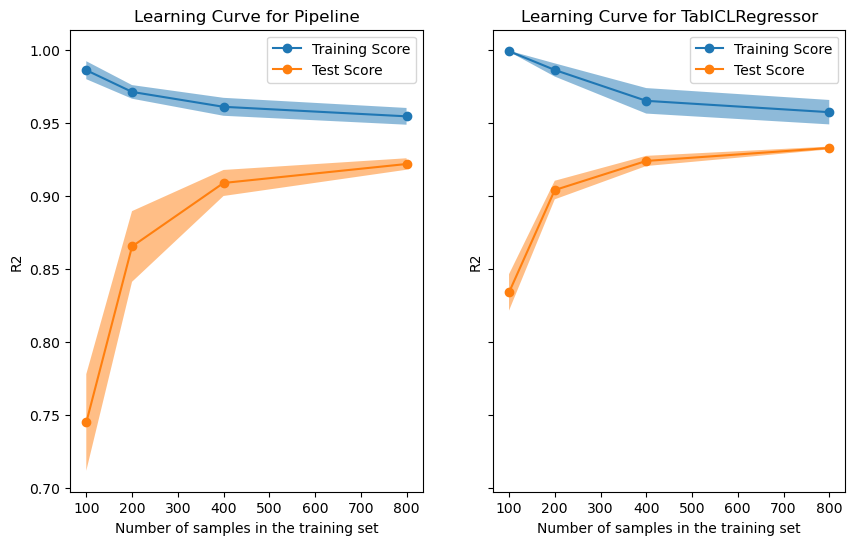

In [39]:
from typing import Any


from tabicl.sklearn.regressor import TabICLRegressor
from time import perf_counter

from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit
import tabicl

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharey=True)

common_params = {
    "X": X,
    "y": y,
    "train_sizes": [100, 200, 400, 800],
    "cv": ShuffleSplit(n_splits=5, test_size=0.2, random_state=0),
    "score_type": "both",
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "R2",
}
tuned_poly_reg_cpu = make_pipeline(
    SplineTransformer(n_knots=10),
    Nystroem(kernel="poly", degree=2, n_components=300, random_state=0),
    RidgeCV(alphas=np.logspace(-6, 6, 13)),
)

for ax_idx, estimator in enumerate([tuned_poly_reg_cpu, tabicl.TabICLRegressor()]):
    print("Computing learning curve for", estimator.__class__.__name__)
    tic = perf_counter()
    LearningCurveDisplay.from_estimator(estimator, **common_params, ax=ax[ax_idx], error_score="raise")
    toc = perf_counter()
    print(f"Time taken: {toc - tic:.2f} seconds")
    handles, label = ax[ax_idx].get_legend_handles_labels()
    ax[ax_idx].legend(handles[:2], ["Training Score", "Test Score"])
    ax[ax_idx].set_title(f"Learning Curve for {estimator.__class__.__name__}")


In [266]:
X_subset = X[:1000]
y_subset = y[:1000]

In [251]:
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.stats import norm
from sklearn.linear_model import TweedieRegressor
from sklearn.model_selection import GridSearchCV


class GaussianQuantileRegressorCV(BaseEstimator, RegressorMixin):
    """Assume that the residuals are Gaussian distributed"""

    def __init__(
        self,
        alphas=np.logspace(-6, 6, 13),
    ):
        self.alphas = alphas

    def fit(self, X, y, sample_weight=None):
        # TODO: expose mean estimator as a parameter and implement
        # cross-fitting procedure to compute the squared residuals if the mean
        # estimator is not a `RidgeCV` with the right choice of `cv` and
        # `scoring` params.
        mean_estimator = RidgeCV(alphas=self.alphas, store_cv_results=True)
        best_alpha_idx = np.flatnonzero(np.asarray(self.alphas) == self.alphas)[0]

        # TODO: expose var estimator as a parameter.
        # Note: TweedieRegressor power=2 should be a good choice for the variance
        # estimator: if the residuals are Gaussian distributed, their squared
        # values are chi-squared distributed and therefore a particular case of
        # the Gamma (Tweedie power=2) distribution. However, in practice power=1.5
        # seems to work a bit better.
        var_estimator = TweedieRegressor(alpha=1e-12, max_iter=1_000, power=1.5)
        # var_estimator = GridSearchCV(
        #     TweedieRegressor(alpha=1e-6, power=2, max_iter=1_000),
        #     param_grid={"alpha": np.logspace(-12, 12, 13), "power": [1.1, 1.3, 1.5, 1.7, 2]},
        #     n_jobs=4,
        # )

        self.mean_estimator_ = mean_estimator.fit(X, y, sample_weight=sample_weight)
        squared_residuals = self.mean_estimator_.cv_results_[:, best_alpha_idx]
        self.var_estimator_ = var_estimator.fit(
            X, squared_residuals, sample_weight=sample_weight
        )
        return self

    def predict(self, X, output_type="mean", alphas=None):
        """Compute conditional distribution parameters.

        If output_type == "mean" or "median" return an array of shape (n_samples,).

        If output_type == "quantile" return an array of shape (n_samples, n_quantiles).

        Since the model assumes Gaussian Y|X, mean and median are the same.

        The variance is computed as exp(log_var), which is the conditional
        variance of Y|X. As a result, any quantile of Y|X is a linear
        transformation of the quantiles of the residuals.
        """
        if output_type in ["mean", "median"]:
            return self.mean_estimator_.predict(X)
        elif output_type == "quantile":
            if alphas is None:
                alphas = [0.1, 0.25, 0.5, 0.75, 0.9]
            alphas = np.asarray(alphas)
            n_samples = X.shape[0]

            mean_X = self.mean_estimator_.predict(X).reshape(n_samples, 1)
            var_X = self.var_estimator_.predict(X).reshape(n_samples, 1)
            return mean_X + np.sqrt(var_X) * norm.ppf(alphas).reshape(
                1, alphas.shape[0]
            )


poly_dist_reg = make_pipeline(
    SplineTransformer(n_knots=20),
    Nystroem(kernel="poly", degree=2, n_components=500, random_state=0),
    GaussianQuantileRegressorCV(),
)
poly_dist_reg.fit(X, y)
poly_dist_reg.predict(
    X, output_type="quantile", alphas=[0.1, 0.25, 0.5, 0.75, 0.9]
).shape

(100000, 5)

In [246]:
# poly_dist_reg[-1].var_estimator_.best_params_

In [247]:
# import pandas as pd

# pd.DataFrame(poly_dist_reg[-1].var_estimator_.cv_results_).sort_values("mean_test_score", ascending=False)

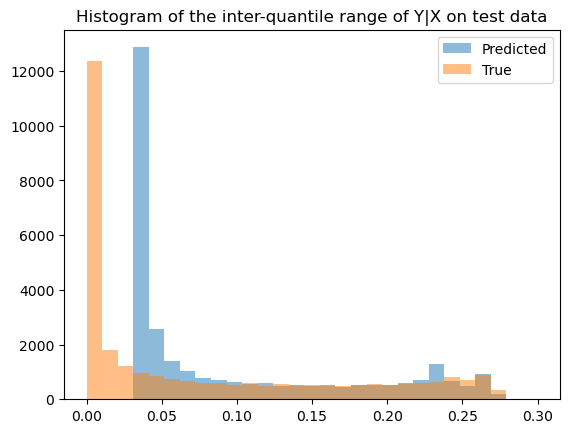

In [252]:
X_test, y_test = make_data(n_samples=int(3e4), seed=2)

predicted_quartiles = poly_dist_reg.predict(X_test, output_type="quantile", alphas=[0.25, 0.75])
predicted_iqr = predicted_quartiles[:, 1] - predicted_quartiles[:, 0]

true_quartiles = true_std(X_test).reshape(-1, 1) * norm.ppf([0.25, 0.75]).reshape(1, 2)
true_iqr = true_quartiles[:, 1] - true_quartiles[:, 0]

bins = np.linspace(0, 0.3, 30)

plt.hist(predicted_iqr, bins=bins, alpha=0.5, label="Predicted")
plt.hist(true_iqr, bins=bins, alpha=0.5, label="True")
plt.title("Histogram of the inter-quantile range of Y|X on test data")
_ = plt.legend()

Plot the IQR map of the poly reg model over the feature space and along side the ground-truth derived from the data generating process:

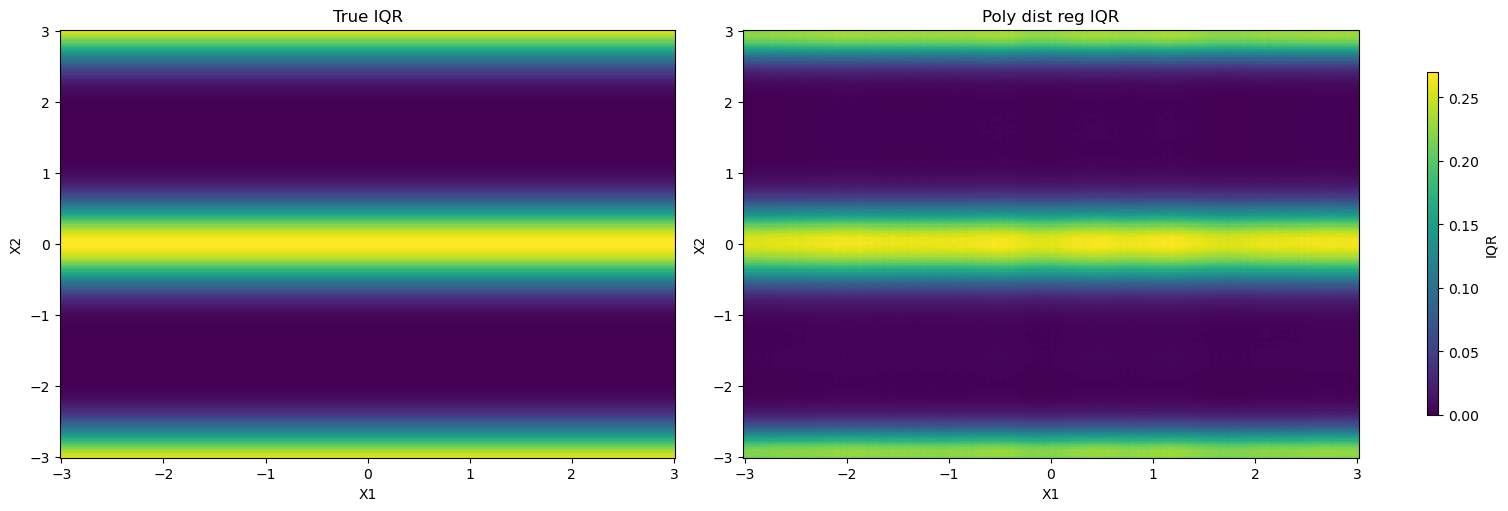

In [259]:
x1 = np.linspace(-3, 3, 200).astype(np.float32)
x2 = np.linspace(-3, 3, 200).astype(np.float32)
X1, X2 = np.meshgrid(x1, x2)

fig, axs = plt.subplots(ncols=2, figsize=(15, 5), constrained_layout=True)
true_quartiles = true_std(np.c_[X1.ravel(), X2.ravel()]).reshape(-1, 1) * norm.ppf([0.25, 0.75]).reshape(1, 2)
true_iqr = true_quartiles[:, 1] - true_quartiles[:, 0]
mesh_true_iqr = axs[0].pcolormesh(X1, X2, true_iqr.reshape(*X1.shape))
axs[0].set(title="True IQR", xlabel="X1", ylabel="X2")

poly_reg_quartiles = poly_dist_reg.predict(np.c_[X1.ravel(), X2.ravel()], output_type="quantile", alphas=[0.25, 0.75])
poly_reg_iqr = poly_reg_quartiles[:, 1] - poly_reg_quartiles[:, 0]
axs[1].pcolormesh(X1, X2, poly_reg_iqr.reshape(*X1.shape))
axs[1].set(title="Poly dist reg IQR", xlabel="X1", ylabel="X2")

_ = fig.colorbar(mesh_true_iqr, ax=axs, shrink=0.8, aspect=30, label='IQR')

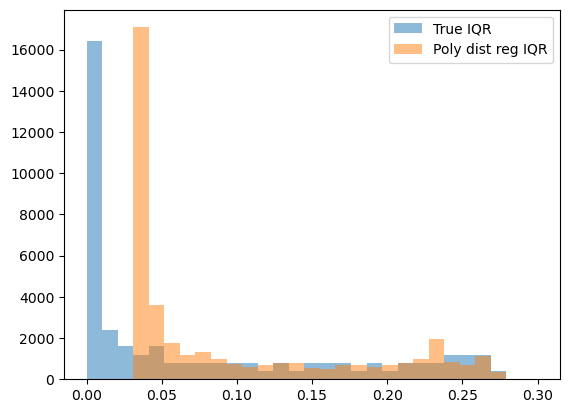

In [260]:
_ = plt.hist(true_iqr, bins=np.linspace(0, 0.3, 30), alpha=0.5, label="True IQR")
_ = plt.hist(poly_reg_iqr, bins=np.linspace(0, 0.3, 30), alpha=0.5, label="Poly dist reg IQR")
_ = plt.legend()

In [267]:
pd.DataFrame(cross_validate(tabicl.TabICLRegressor(n_estimators=1), X_subset, y_subset, cv=5))


,fit_time,score_time,test_score
0,0.171552,0.154141,0.926309
1,0.109177,0.180757,0.935378
2,0.118239,0.159078,0.928156
3,0.097614,0.156134,0.947192
4,0.096356,0.159181,0.947992


In [268]:
pd.DataFrame(cross_validate(tabicl.TabICLRegressor(n_estimators=2), X_subset, y_subset, cv=5))


,fit_time,score_time,test_score
0,0.139338,0.317250,0.926282
1,0.103065,0.335129,0.935346
2,0.100529,0.335561,0.928242
3,0.103385,0.299704,0.947180
4,0.101126,0.306599,0.948089


In [269]:
pd.DataFrame(cross_validate(tabicl.TabICLRegressor(n_estimators=4), X_subset, y_subset, cv=5))


,fit_time,score_time,test_score
0,0.624477,0.695555,0.926364
1,0.103305,0.681758,0.934947
2,0.100106,0.692934,0.928560
3,0.101976,0.683490,0.947573
4,0.106109,0.681492,0.948068


In [264]:
pd.DataFrame(cross_validate(tabicl.TabICLRegressor(n_estimators=8), X_subset, y_subset, cv=5))


,fit_time,score_time,test_score
0,0.128140,0.175243,0.856934
1,0.102599,0.223856,0.913540
2,0.104021,0.183873,0.891796
3,0.103270,0.248431,0.915894
4,0.103205,0.247039,0.896748


In [270]:
pd.DataFrame(cross_validate(tabicl.TabICLRegressor(n_estimators=16), X_subset, y_subset, cv=5))


,fit_time,score_time,test_score
0,0.115262,0.616148,0.926364
1,0.101989,0.662047,0.934947
2,0.106434,0.689047,0.928560
3,0.100904,0.714159,0.947573
4,0.102060,0.661582,0.948068


In [271]:
treg = tabicl.TabICLRegressor(n_estimators=8).fit(X_subset, y_subset)
predicted_quartiles_treg = treg.predict(X_test, output_type="quantiles", alphas=[0.25, 0.75])
predicted_quartiles_treg

array([[-4.2354721e-03, -3.0148528e-03],
       [-2.9411981e-01, -2.0721185e-01],
       [ 8.5729780e-04,  2.0837870e-03],
       ...,
       [-4.3527195e-03, -4.0873173e-03],
       [ 6.6509426e-01,  1.0000079e+00],
       [-3.4431344e-01, -2.6804796e-01]], shape=(30000, 2), dtype=float32)

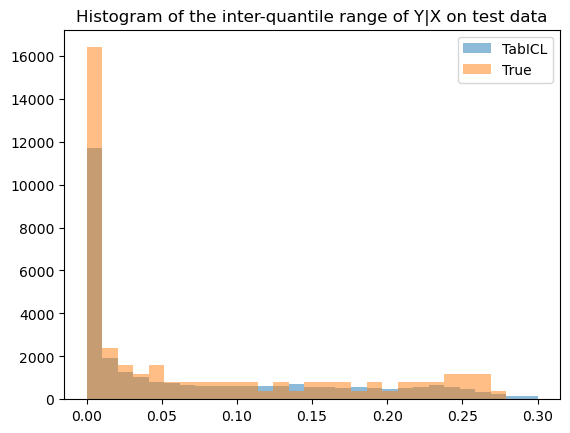

In [272]:
plt.hist(predicted_quartiles_treg[:, -1] - predicted_quartiles_treg[:, 0], bins=bins, alpha=0.5, label="TabICL")
plt.hist(true_iqr, bins=bins, alpha=0.5, label="True")
plt.title("Histogram of the inter-quantile range of Y|X on test data")
_ = plt.legend()


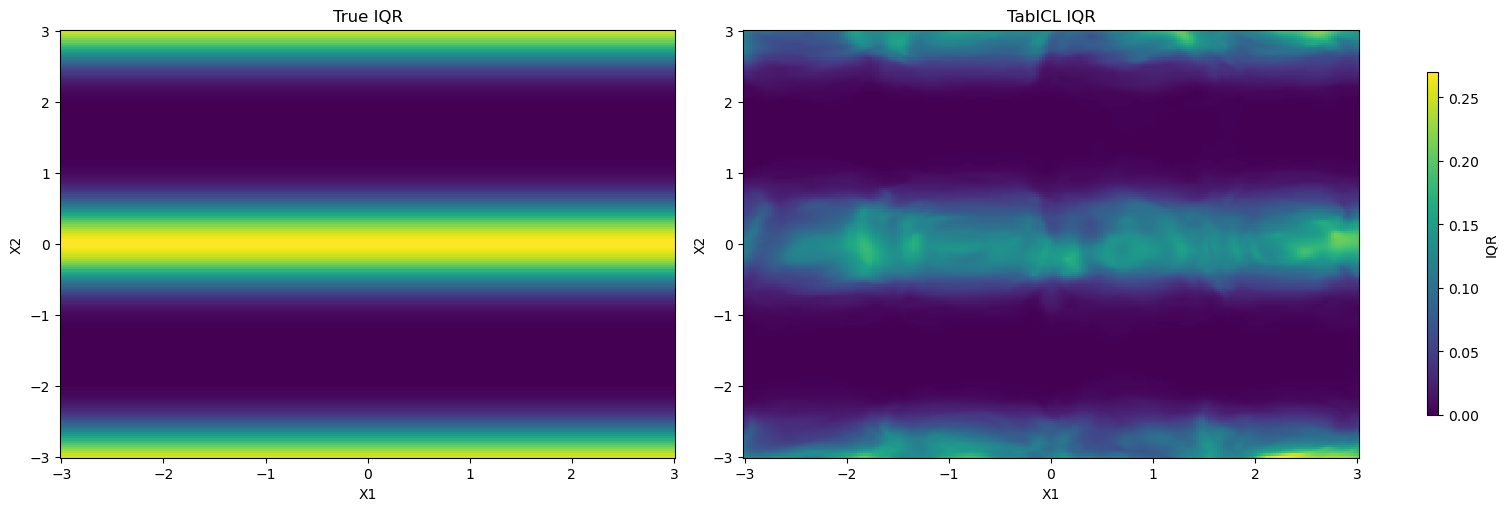

In [274]:
x1 = np.linspace(-3, 3, 200).astype(np.float32)
x2 = np.linspace(-3, 3, 200).astype(np.float32)
X1, X2 = np.meshgrid(x1, x2)

fig, axs = plt.subplots(ncols=2, figsize=(15, 5), constrained_layout=True)
true_quartiles = true_std(np.c_[X1.ravel(), X2.ravel()]).reshape(-1, 1) * norm.ppf([0.25, 0.75]).reshape(1, 2)
true_iqr = true_quartiles[:, 1] - true_quartiles[:, 0]
mesh_true_iqr = axs[0].pcolormesh(X1, X2, true_iqr.reshape(*X1.shape))
axs[0].set(title="True IQR", xlabel="X1", ylabel="X2")

treg_quartiles = treg.predict(np.c_[X1.ravel(), X2.ravel()], output_type="quantiles", alphas=[0.25, 0.75])
treg_iqr = treg_quartiles[:, 1] - treg_quartiles[:, 0]
axs[1].pcolormesh(X1, X2, treg_iqr.reshape(*X1.shape))
axs[1].set(title="TabICL IQR", xlabel="X1", ylabel="X2")

_ = fig.colorbar(mesh_true_iqr, ax=axs, shrink=0.8, aspect=30, label='IQR')